In [ ]:

# import mercantile
# import requests
# from vt2geojson.tools import vt_bytes_to_geojson
# import geopandas as gpd
# import pandas as pd


# from shapely.geometry import box
# from shapely.geometry import shape


# #from osm2geojson import json2geojson

# import logging
# from datetime import datetime, timezone
# from tqdm import tqdm
# import json

# import os

# from pathlib import Path

In [ ]:
import geopandas as gpd
import pandas as pd

import mercantile
from tqdm import tqdm
import json

from datetime import datetime, timezone
import requests

from vt2geojson.tools import vt_bytes_to_geojson


<Axes: >

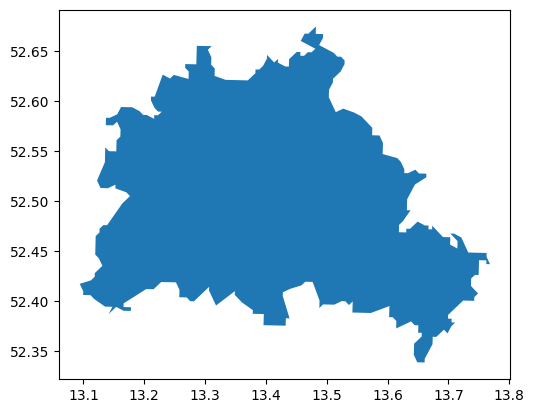

In [4]:


### get shape of Berlin
bland = gpd.read_file("https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json")
bland=bland[bland["id"].isin(["DE-BE"])]
bland.plot()



In [5]:


### get the number of tiles that would be downloaded

# Get the bounds of the polygon
polygon = bland.dissolve().geometry.iloc[0]
minx, miny, maxx, maxy = polygon.bounds

# === Define bounding box (Berlin or any area) ===
bbox = [minx, miny, maxx, maxy]  # must be defined earlier

# === Get intersecting tiles at zoom 14 ===
tiles = list(mercantile.tiles(*bbox, zooms=[14]))
total_tiles = len(tiles)

total_tiles



832

In [6]:
polygon = bland.dissolve().geometry.iloc[0]

from shapely.geometry import box
import mercantile
from tqdm import tqdm  # Import tqdm

# Assuming `polygon` is your shapely Polygon (already from dissolve)
# `tiles` is your list of mercantile.Tile objects

filtered_tiles = []

for tile in tqdm(tiles):
    # Get tile bounds as a shapely box
    tile_bounds = mercantile.bounds(tile)
    tile_polygon = box(tile_bounds.west, tile_bounds.south, tile_bounds.east, tile_bounds.north)
    tile_centroid = tile_polygon.centroid

    # Check if the tile intersects the polygon
    if polygon.intersects(tile_centroid):
        filtered_tiles.append(tile)

  0%|          | 0/832 [00:00<?, ?it/s]

100%|██████████| 832/832 [00:00<00:00, 39160.83it/s]


Text(0.5, 1.0, 'Berlin Boundary and mapillary tiles for polygon, n=399')

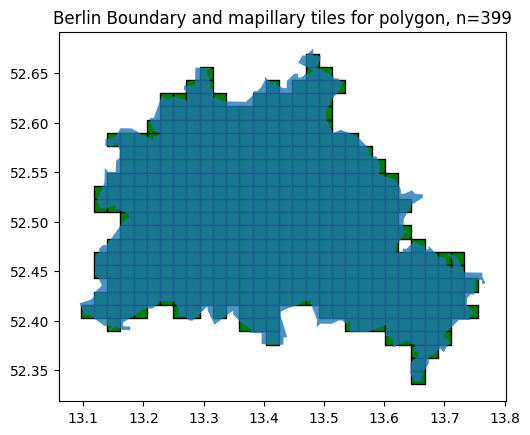

In [7]:


from shapely.geometry import Polygon
from shapely.geometry import MultiPolygon

# Create a list of polygons
polygons = []
for tile in filtered_tiles:
    minx, miny, maxx, maxy = mercantile.bounds(tile)
    polygons.append(Polygon([(minx, miny), (minx, maxy), (maxx, maxy), (maxx, miny)]))

# Combine the polygons into a single multi-polygon
multi_polygon = MultiPolygon(polygons)

gdf = gpd.GeoDataFrame(geometry=[multi_polygon])
#gdf.plot()

#bland.plot(ax=gdf.plot(color='green', edgecolor='black'), alpha=0.8)
ax = gdf.plot(color='green', edgecolor='black')
bland.plot(ax=ax, alpha=0.8)
ax.set_title("Berlin Boundary and mapillary tiles for polygon, n="+str(len(filtered_tiles)))



In [33]:


# Load your access token
with open("config_mapillary_privat.json") as f:
    ACCESS_TOKEN = json.load(f)["ACCESS_TOKEN"]


# Get current date in YYYY-MM-DD format
current_date = datetime.now().strftime('%Y-%m-%d')

# Use existing variables
tile_layer = 'traffic_sign'  # already defined
tile_coverage = "mly_map_feature_traffic_sign"



# tiles is already defined and filtered
total_tiles = len(tiles)

#filetered_tiles_use = filtered_tiles[100:102]  
filetered_tiles_use = filtered_tiles

gdf_all = None

for i, tile in enumerate(tqdm(filetered_tiles_use, desc="Processing tiles"), start=1):
    url = f"https://tiles.mapillary.com/maps/vtp/{tile_coverage}/2/{tile.z}/{tile.x}/{tile.y}?access_token={ACCESS_TOKEN}"
    response = requests.get(url)
    
    if response.status_code != 200:
        continue

    try:
        geojson = vt_bytes_to_geojson(response.content, tile.x, tile.y, tile.z, layer=tile_layer)
        features = geojson.get("features", [])

        if not features:
            print (f"No features found in tile {tile.x}/{tile.y}.")
            continue

        gdf_tile = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")

        gdf_tile['first_seen_at'] = gdf_tile['first_seen_at'].apply(lambda x: datetime.fromtimestamp(x / 1000, tz=timezone.utc))
        gdf_tile['first_seen_at'] = gdf_tile['first_seen_at'].dt.strftime('%Y-%m-%d')
        gdf_tile['last_seen_at'] = gdf_tile['last_seen_at'].apply(lambda x: datetime.fromtimestamp(x / 1000, tz=timezone.utc))
        gdf_tile['last_seen_at'] = gdf_tile['last_seen_at'].dt.strftime('%Y-%m-%d')

        #gdf_tile['tile_x'] = tile.x
        #gdf_tile['tile_y'] = tile.y

        if gdf_all is None:
            gdf_all = gdf_tile
        else:
            gdf_all = gpd.GeoDataFrame(pd.concat([gdf_all, gdf_tile], ignore_index=True))
    except Exception as e:
        print (f"Error processing tile {tile.x}/{tile.y}: {e}")
      #  logging.warning(f"Error processing tile {tile.x}/{tile.y}: {e}")

#gdf_all

final_filename = f"mapillary_map-feature-data_berlin_{current_date}.parquet"
gdf_all.to_parquet(final_filename, index=False)



Processing tiles:  14%|█▍        | 55/399 [00:25<02:30,  2.28it/s]

Error processing tile 8793/5375: name 'logging' is not defined


Processing tiles:  14%|█▍        | 56/399 [00:25<02:25,  2.36it/s]

Error processing tile 8793/5376: name 'logging' is not defined


Processing tiles:  91%|█████████ | 362/399 [03:18<00:24,  1.52it/s]

...

Processing tiles:  96%|█████████▌| 383/399 [03:28<00:07,  2.07it/s]

Error processing tile 8814/5382: name 'logging' is not defined


Processing tiles:  96%|█████████▌| 384/399 [03:28<00:06,  2.29it/s]

Error processing tile 8814/5383: name 'logging' is not defined


Processing tiles: 100%|██████████| 399/399 [03:36<00:00,  1.84it/s]


In [34]:
gdf_all

,geometry,first_seen_at,id,last_seen_at,value
0,POINT (13.09673 52.41332),2015-11-18,1391186787929268,2015-11-18,information--general-directions--g1
1,POINT (13.10878 52.41408),2015-11-18,1178445959261416,2016-03-25,warning--wild-animals--g1
2,POINT (13.0971 52.41321),2017-06-25,1696373427217755,2024-05-09,regulatory--no-parking--g1
3,POINT (13.10394 52.40669),2019-06-11,395689434851066,2019-06-11,regulatory--no-parking--g1
4,POINT (13.0961 52.41325),2015-11-18,483876509493610,2015-11-18,regulatory--maximum-speed-limit-50--g1
...,...,...,...,...,...
348888,POINT (13.75132 52.41046),2020-05-09,940194036739663,2021-09-14,regulatory--keep-right--g1
348889,POINT (13.75013 52.40777),2019-06-30,1260813321017851,2021-09-14,regulatory--shared-path-pedestrians-and-bicycl...
348890,POINT (13.75327 52.41479),2017-05-14,304906801194963,2023-04-10,regulatory--no-parking--g1
348891,POINT (13.75086 52.41488),2022-01-10,934980713814996,2022-01-10,regulatory--priority-road--g1


In [35]:
# gdf_all.explore(
#     tiles="CartoDB positron",
#     popup=True,
#     tooltip=["value", "first_seen_at", "last_seen_at"]
# )

In [ ]:
# Tempo 30 Schilder in Berlin
gdf_all[gdf_all.value=="regulatory--maximum-speed-limit-30--g1"]

,geometry,first_seen_at,id,last_seen_at,value
16,POINT (13.09577 52.41317),2017-06-25,1696254303896334,2024-05-09,regulatory--maximum-speed-limit-30--g1
19,POINT (13.0984 52.41372),2015-11-18,514885479523123,2022-04-30,regulatory--maximum-speed-limit-30--g1
58,POINT (13.09609 52.41348),2018-05-05,469515337590994,2018-05-05,regulatory--maximum-speed-limit-30--g1
70,POINT (13.10911 52.41425),2022-04-30,130052272956782,2024-05-09,regulatory--maximum-speed-limit-30--g1
80,POINT (13.09625 52.41346),2018-05-05,2962802007265985,2018-05-05,regulatory--maximum-speed-limit-30--g1
...,...,...,...,...,...
348827,POINT (13.75357 52.4149),2016-07-21,2537492489881022,2023-04-10,regulatory--maximum-speed-limit-30--g1
348835,POINT (13.73848 52.41555),2023-04-10,917828369425950,2023-04-10,regulatory--maximum-speed-limit-30--g1
348844,POINT (13.75313 52.41399),2016-07-21,793872791232845,2022-01-10,regulatory--maximum-speed-limit-30--g1
348871,POINT (13.74266 52.41539),2023-04-10,701865428384592,2023-04-10,regulatory--maximum-speed-limit-30--g1


In [ ]:
# Tempo 30 Schilder in Berlin, wenn sie mindest 2 mal im Abstand von 6 Monaten gesehen wurden


In [38]:
from datetime import datetime

def months_between(date1, date2):
    d1 = datetime.strptime(date1, "%Y-%m-%d")
    d2 = datetime.strptime(date2, "%Y-%m-%d")
    return abs((d2.year - d1.year) * 12 + d2.month - d1.month)

df_6months = gdf_all[
    gdf_all.apply(lambda row: months_between(row['first_seen_at'], row['last_seen_at']) >= 6, axis=1)
]
df_6months[df_6months.value == "regulatory--maximum-speed-limit-30--g1"]

,geometry,first_seen_at,id,last_seen_at,value
16,POINT (13.09577 52.41317),2017-06-25,1696254303896334,2024-05-09,regulatory--maximum-speed-limit-30--g1
19,POINT (13.0984 52.41372),2015-11-18,514885479523123,2022-04-30,regulatory--maximum-speed-limit-30--g1
70,POINT (13.10911 52.41425),2022-04-30,130052272956782,2024-05-09,regulatory--maximum-speed-limit-30--g1
99,POINT (13.09861 52.41373),2018-03-25,514100952934909,2022-06-12,regulatory--maximum-speed-limit-30--g1
483,POINT (13.11834 52.5112),2020-04-18,561519231920106,2023-09-26,regulatory--maximum-speed-limit-30--g1
...,...,...,...,...,...
348081,POINT (13.70469 52.40236),2020-09-15,193357762649438,2022-02-26,regulatory--maximum-speed-limit-30--g1
348735,POINT (13.7523 52.42938),2015-07-01,303813858048031,2025-02-11,regulatory--maximum-speed-limit-30--g1
348827,POINT (13.75357 52.4149),2016-07-21,2537492489881022,2023-04-10,regulatory--maximum-speed-limit-30--g1
348844,POINT (13.75313 52.41399),2016-07-21,793872791232845,2022-01-10,regulatory--maximum-speed-limit-30--g1


In [39]:
df_6months[df_6months.value == "regulatory--maximum-speed-limit-30--g1"].explore(
    tiles="CartoDB positron",
    popup=True,
    tooltip=["value", "first_seen_at", "last_seen_at"]
)